In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"

EVENTS = RAW_DIR / "events.csv"

print(RAW_DIR)

f:\annuspeaks.com\recommendation-system\data\raw


## User Activity

In [2]:
user_activity = {}

for chunk in pd.read_csv(
    EVENTS,
    usecols=["visitorid", "event"],
    chunksize=250_000
):
    counts = chunk.groupby("visitorid").size()
    for uid, count in counts.items():
        user_activity[uid] = user_activity.get(uid, 0) + count

user_activity = pd.Series(user_activity)

print("Users:", f"{len(user_activity):,}")
print(user_activity.describe())

Users: 1,407,580
count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
dtype: float64


## Product popularity

In [3]:
product_activity = {}

for chunk in pd.read_csv(
    EVENTS,
    usecols=["itemid"],
    chunksize=250_000
):
    counts = chunk["itemid"].value_counts()
    for item, count in counts.items():
        product_activity[item] = product_activity.get(item, 0) + count

product_activity = pd.Series(product_activity)

print("Products:", f"{len(product_activity):,}")
print(product_activity.describe())

Products: 235,061
count    235061.000000
mean         11.725046
std          37.032101
min           1.000000
25%           1.000000
50%           3.000000
75%           9.000000
max        3412.000000
dtype: float64


## Event distribution

In [4]:
event_counts = pd.Series(dtype="int64")

for chunk in pd.read_csv(
    EVENTS,
    usecols=["event"],
    chunksize=250_000
):
    event_counts = event_counts.add(
        chunk["event"].value_counts(),
        fill_value=0
    )

event_counts = event_counts.astype(int)
print(event_counts)

event
addtocart        69332
transaction      22457
view           2664312
dtype: int64


## User-item sparsity

In [5]:
unique_users = len(user_activity)
unique_items = len(product_activity)

total_possible = unique_users * unique_items
observed_interactions = 0

for chunk in pd.read_csv(
    EVENTS,
    usecols=["visitorid", "itemid"],
    chunksize=250_000
):
    observed_interactions += len(chunk)

print("Users:", unique_users)
print("Items:", unique_items)
print("Potential user-item pairs:", f"{total_possible:,}")
print("Event rows:", f"{observed_interactions:,}")
print("Approximate interaction density:",
      observed_interactions / total_possible)

Users: 1407580
Items: 235061
Potential user-item pairs: 330,867,162,380
Event rows: 2,756,101
Approximate interaction density: 8.32993210983756e-06


## Temporal behavior

In [6]:
time_min = None
time_max = None
daily_events = {}

for chunk in pd.read_csv(
    EVENTS,
    usecols=["timestamp"],
    chunksize=250_000
):
    ts = pd.to_datetime(
        chunk["timestamp"],
        unit="ms",
        errors="coerce"
    )

    time_min = ts.min() if time_min is None else min(time_min, ts.min())
    time_max = ts.max() if time_max is None else max(time_max, ts.max())

    daily = ts.dt.date.value_counts()
    for day, count in daily.items():
        daily_events[day] = daily_events.get(day, 0) + count

print("Start:", time_min)
print("End:", time_max)

Start: 2015-05-03 03:00:04.384000
End: 2015-09-18 02:59:47.788000


## Basic long-tail analysis

In [7]:
sorted_products = product_activity.sort_values(ascending=False)

for pct in [0.01, 0.05, 0.10]:
    n = max(1, int(len(sorted_products) * pct))
    share = sorted_products.head(n).sum() / sorted_products.sum()
    print(f"Top {pct:.0%} products account for {share:.2%} of events")

Top 1% products account for 22.95% of events
Top 5% products account for 49.32% of events
Top 10% products account for 64.03% of events


## Visualization

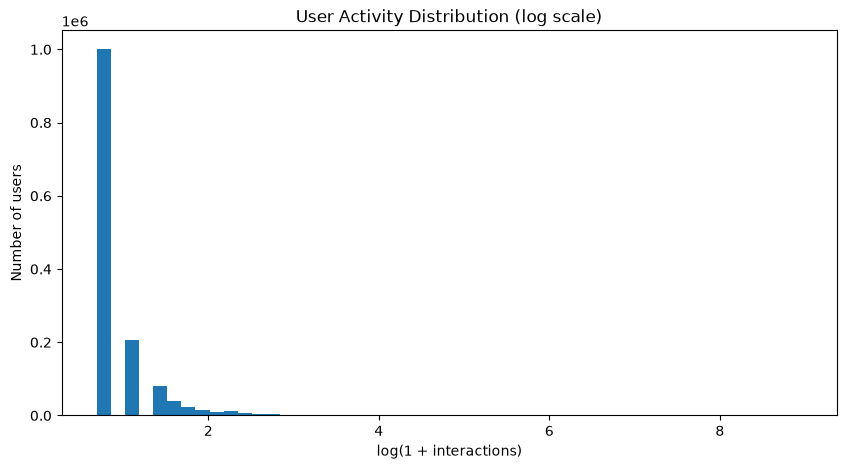

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(user_activity.values), bins=50)
plt.title("User Activity Distribution (log scale)")
plt.xlabel("log(1 + interactions)")
plt.ylabel("Number of users")
plt.show()

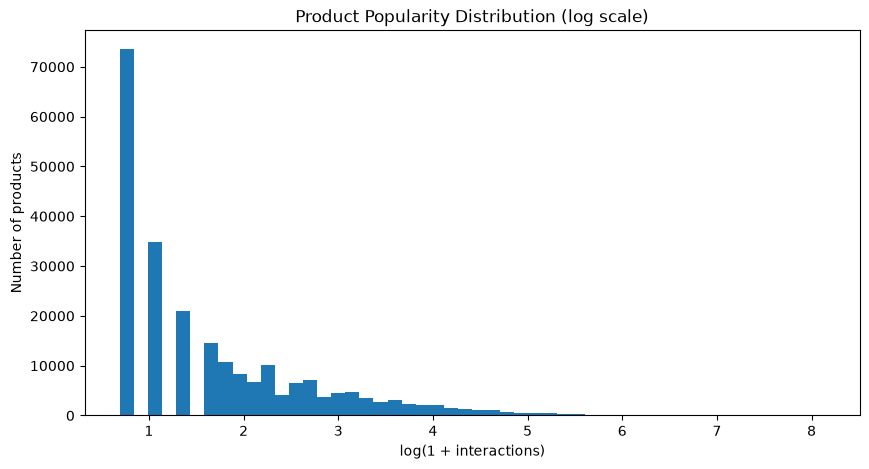

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(product_activity.values), bins=50)
plt.title("Product Popularity Distribution (log scale)")
plt.xlabel("log(1 + interactions)")
plt.ylabel("Number of products")
plt.show()

## Interactions per User

In [10]:
user_interactions = {}

for chunk in pd.read_csv(
    EVENTS,
    usecols=["visitorid"],
    chunksize=250_000
):
    counts = chunk["visitorid"].value_counts()

    for user, count in counts.items():
        user_interactions[user] = (
            user_interactions.get(user, 0) + int(count)
        )

user_interactions = pd.Series(user_interactions)

print("Users:", f"{len(user_interactions):,}")
print("\nInteractions per user:")
print(user_interactions.describe())

print("\nMedian:", user_interactions.median())
print("Mean:", user_interactions.mean())
print("Max:", user_interactions.max())

Users: 1,407,580

Interactions per user:
count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
dtype: float64

Median: 1.0
Mean: 1.9580421716705267
Max: 7757


# Interactions per product

In [11]:
# Interactions per product

product_interactions = {}

for chunk in pd.read_csv(
    EVENTS,
    usecols=["itemid"],
    chunksize=250_000
):
    counts = chunk["itemid"].value_counts()

    for item, count in counts.items():
        product_interactions[item] = (
            product_interactions.get(item, 0) + int(count)
        )

product_interactions = pd.Series(product_interactions)

print("Products:", f"{len(product_interactions):,}")
print("\nInteractions per product:")
print(product_interactions.describe())

print("\nMedian:", product_interactions.median())
print("Mean:", product_interactions.mean())
print("Max:", product_interactions.max())

Products: 235,061

Interactions per product:
count    235061.000000
mean         11.725046
std          37.032101
min           1.000000
25%           1.000000
50%           3.000000
75%           9.000000
max        3412.000000
dtype: float64

Median: 3.0
Mean: 11.725045839165153
Max: 3412


## Category distribution

In [12]:
# Category distribution

category_map = {}

for name in [
    "item_properties_part1.csv",
    "item_properties_part2.csv"
]:
    path = RAW_DIR / name

    for chunk in pd.read_csv(
        path,
        usecols=["timestamp", "itemid", "property", "value"],
        chunksize=250_000
    ):
        category_rows = chunk[
            chunk["property"].astype(str).str.lower() == "categoryid"
        ].copy()

        for item, group in category_rows.groupby("itemid"):
            latest = group.sort_values("timestamp").iloc[-1]
            category_map[item] = latest["value"]

print("Products with category:", f"{len(category_map):,}")

category_interactions = {}

for chunk in pd.read_csv(
    EVENTS,
    usecols=["itemid"],
    chunksize=250_000
):
    chunk["category"] = chunk["itemid"].map(category_map)

    counts = chunk["category"].dropna().value_counts()

    for category, count in counts.items():
        category_interactions[category] = (
            category_interactions.get(category, 0) + int(count)
        )

category_interactions = pd.Series(category_interactions).sort_values(
    ascending=False
)

print("\nCategories represented in interactions:",
      f"{len(category_interactions):,}")

display(category_interactions.head(20))

Products with category: 417,053

Categories represented in interactions: 1,129


1051    75216
1483    66308
959     52278
342     46852
683     38887
491     36944
1279    34381
5       29716
646     28240
196     27688
48      27454
1173    24572
1135    23875
333     22878
1578    22182
84      21920
589     21354
1221    18726
1650    18378
1375    17957
dtype: int64

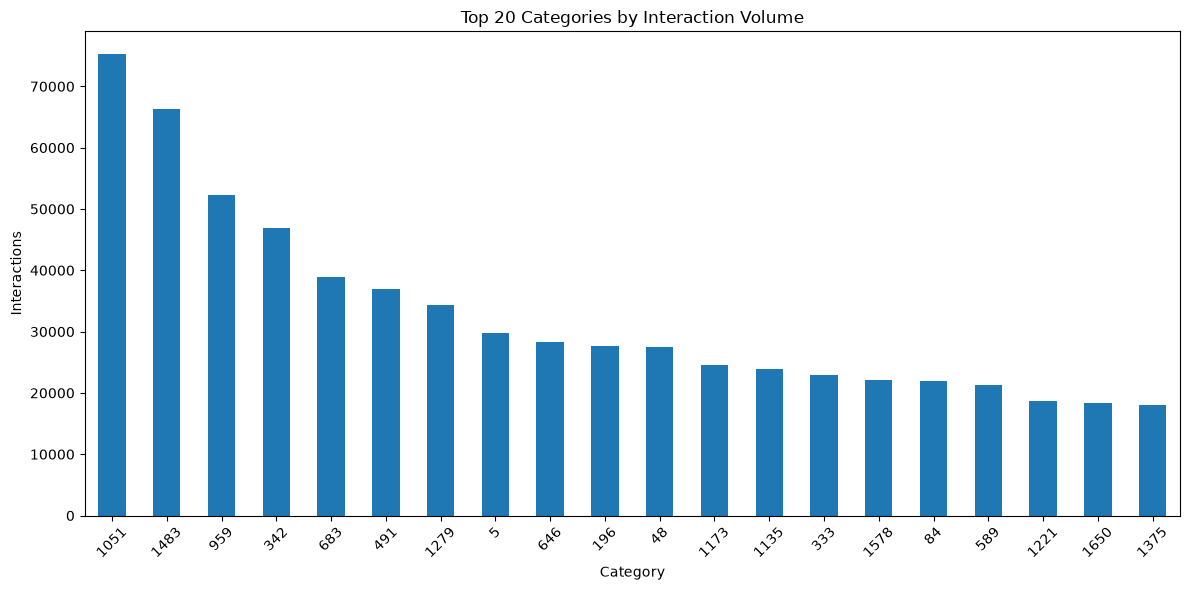

In [13]:
plt.figure(figsize=(12, 6))

category_interactions.head(20).plot(kind="bar")

plt.title("Top 20 Categories by Interaction Volume")
plt.xlabel("Category")
plt.ylabel("Interactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analyze rating distribution if a rating-like property is identified during inventory

In [14]:
# Rating-like property check

rating_candidates = set()

for name in [
    "item_properties_part1.csv",
    "item_properties_part2.csv"
]:
    path = RAW_DIR / name

    for chunk in pd.read_csv(
        path,
        usecols=["property"],
        chunksize=250_000
    ):
        props = chunk["property"].astype(str).str.lower()

        matches = chunk.loc[
            props.str.contains(
                "rating|review|score",
                regex=True,
                na=False
            ),
            "property"
        ]

        rating_candidates.update(matches.astype(str).unique())

print("Rating-like property IDs found:")
print(sorted(rating_candidates))

Rating-like property IDs found:
[]
